In [26]:
import joblib
import numpy as np
import pandas as pd
import optuna
X_train = joblib.load("../features/X_train.pkl")
X_val = joblib.load("../features/X_val.pkl")
X_test = joblib.load("../features/X_test.pkl")

y_train = joblib.load("../features/y_train.pkl")
y_val = joblib.load("../features/y_val.pkl")
y_test = joblib.load("../features/y_test.pkl")

print(X_train.shape)

(1134, 11)


e:\conda\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.hstack([y_train, y_val])

In [33]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
def rf_objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt","log2"]),
        "class_weight": "balanced",
        "n_jobs": -1,
        "random_state": 42
    }

    model = RandomForestClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    score = cross_val_score(
        model,
        X_train_full,
        y_train_full,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return score


In [35]:
study_rf = optuna.create_study(direction="maximize")

study_rf.optimize(rf_objective, n_trials=200)

[I 2026-03-10 00:25:01,795] A new study created in memory with name: no-name-fcea8389-e430-4571-9bdb-bb1c6fa18250
[I 2026-03-10 00:25:05,019] Trial 0 finished with value: 0.8699046821973908 and parameters: {'n_estimators': 411, 'max_depth': 16, 'min_samples_split': 3, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8699046821973908.
[I 2026-03-10 00:25:07,986] Trial 1 finished with value: 0.850506527487312 and parameters: {'n_estimators': 575, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8699046821973908.
[I 2026-03-10 00:25:10,519] Trial 2 finished with value: 0.8539619545147316 and parameters: {'n_estimators': 501, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8699046821973908.
[I 2026-03-10 00:25:10,728] Trial 3 finished with value: 0.8575522412716412 and parameters: {'n_estimators': 101, 'max_depth': 13, 'm

In [36]:
print(study_rf.best_params)
print(study_rf.best_value)

{'n_estimators': 147, 'max_depth': 3, 'min_samples_split': 17, 'min_samples_leaf': 10, 'max_features': 'log2'}
0.8835104010084269


In [37]:
best_rf = RandomForestClassifier(
    **study_rf.best_params,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train_full, y_train_full)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",147
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",17
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [38]:
val_probs = best_rf.predict_proba(X_val)[:,1]

e:\conda\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [39]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.linspace(0.05,0.95,50)

results = []

for t in thresholds:
    
    preds = (val_probs >= t).astype(int)
    
    precision = precision_score(y_val,preds)
    recall = recall_score(y_val,preds)
    f1 = f1_score(y_val,preds)
    
    results.append((t,precision,recall,f1))

results = np.array(results)

e:\conda\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\conda\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\conda\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\conda\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1833: 

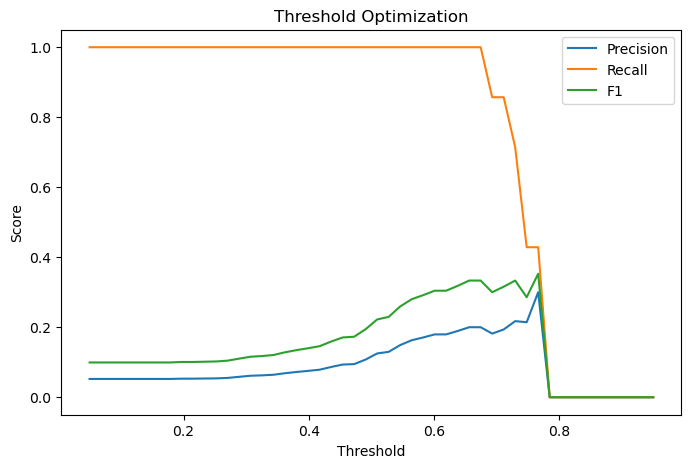

In [40]:
plt.figure(figsize=(8,5))

plt.plot(results[:,0],results[:,1],label="Precision")
plt.plot(results[:,0],results[:,2],label="Recall")
plt.plot(results[:,0],results[:,3],label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")
plt.legend()

plt.show()

In [41]:
best_index = np.argmax(results[:,3])
best_threshold = results[best_index,0]

print("Best Threshold:",best_threshold)
print("Best F1:",results[best_index,3])

Best Threshold: 0.7663265306122449
Best F1: 0.35294117647058826


In [42]:

best_threshold = float(best_threshold)

val_preds = (val_probs >= best_threshold).astype(int)

In [43]:
print("Accuracy:", accuracy_score(y_val,val_preds))
print("Precision:", precision_score(y_val,val_preds))
print("Recall:", recall_score(y_val,val_preds))
print("F1:", f1_score(y_val,val_preds))
print("ROC-AUC:", roc_auc_score(y_val,val_probs))

Accuracy: 0.9547325102880658
Precision: 0.3
Recall: 0.42857142857142855
F1: 0.35294117647058826
ROC-AUC: 0.9455205811138014


In [44]:
print(classification_report(y_val,val_preds))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       236
           1       0.30      0.43      0.35         7

    accuracy                           0.95       243
   macro avg       0.64      0.70      0.66       243
weighted avg       0.96      0.95      0.96       243



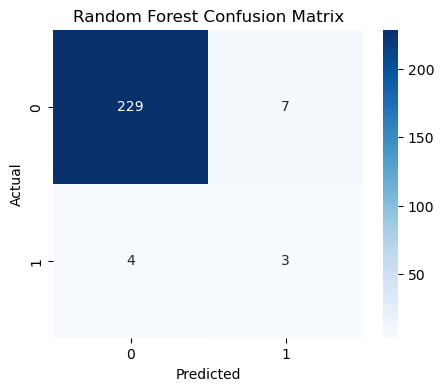

In [45]:
cm = confusion_matrix(y_val,val_preds)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

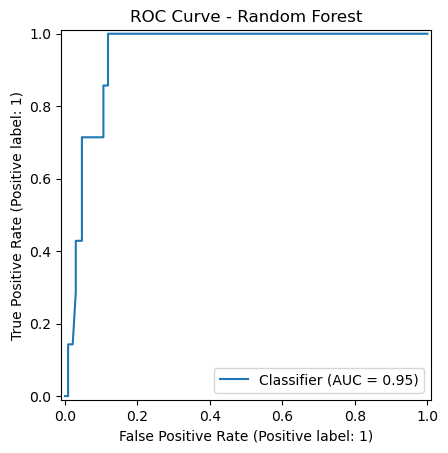

In [46]:
RocCurveDisplay.from_predictions(
    y_val,
    val_probs
)

plt.title("ROC Curve - Random Forest")

plt.show()

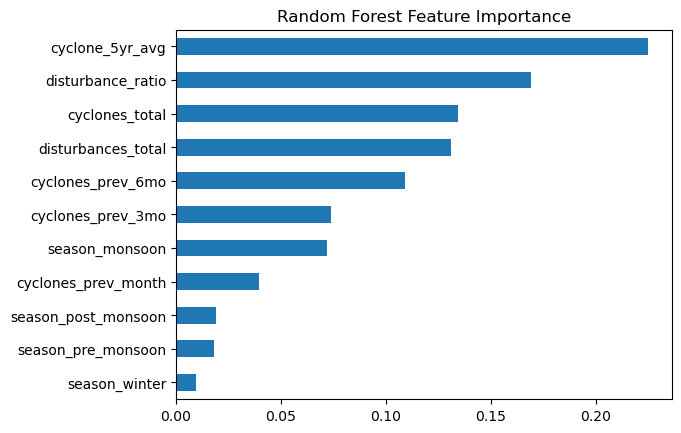

In [47]:
feature_names = [
    "cyclones_total",
    "disturbances_total",
    "disturbance_ratio",
    "cyclone_5yr_avg",
    "season_monsoon",
    "season_post_monsoon",
    "season_pre_monsoon",
    "season_winter",
    "cyclones_prev_month",
    "cyclones_prev_3mo",
    "cyclones_prev_6mo"
]

importances = pd.Series(
    rf.feature_importances_,
    index=feature_names
)

importances.sort_values().plot.barh()

plt.title("Random Forest Feature Importance")

plt.show()

In [ ]:
test_probs = rf.predict_proba(X_test)[:,1]
test_preds = rf.predict(X_test)

print("TEST ROC-AUC:", roc_auc_score(y_test, test_probs))
print("TEST F1:", f1_score(y_test, test_preds))

TEST ROC-AUC: 0.9073611977542109
TEST F1: 0.45454545454545453


In [49]:
joblib.dump(
    rf,
    "../models/random_forest_model.pkl"
)

['../models/random_forest_model.pkl']